#  Machine Learning: Predicción de Precios y Detección de Valor
## Fase 4 - Modelado Predictivo de Barcelona

**Objetivo:** Construir un modelo de regresión para estimar el precio por m² basado en fundamentales socioeconómicos y detectar desviaciones de mercado.

---

## 🧬 Hoja de Ruta
1. [Carga del Dataset Enriquecido](#1-carga)
2. [Ingeniería de Características para ML](#2-prep)
3. [Entrenamiento del Modelo (Random Forest)](#3-training)
4. [Evaluación de Precisión (MAE, RMSE, R²)](#4-evaluation)
5. [Identificación de Oportunidades (Análisis de Residuos) ⭐](#5-residuos)
6. [Importancia de las Variables (Feature Importance)](#6-importance)
7. [Exportación del Modelo de Valor](#7-export)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# 1. CARGA DEL DATASET DE INTELIGENCIA (Resultado de Fase 3)
data_path = Path("../data/neighborhood_intelligence_final_v2.csv")
df = pd.read_csv(data_path)

print(f"✅ Inteligencia cargada: {df.shape[0]} barrios y {df.shape[1]} variables.")
display(df.head(2))

✅ Inteligencia cargada: 73 barrios y 19 variables.


,barrio_id,barrio_nombre,distrito_nombre,avg_venta_23,avg_alquiler_23,avg_venta_22,renta_bruta_llar,indice_gini,superficie_media_m2,antiguedad_media_bloque,num_propietarios_juridica,num_propietarios_fisica,pct_propietarios_extranjeros,gross_yield,effort_rate,price_growth_1y,pct_juridica,cluster,segmento
0,1,el Raval,Ciutat Vella,3769.646932,946.812927,3297.837443,38545.285714,33.795238,65.876190,101.932761,0,42,15.00000,4.575265,37.790232,14.306633,0.0,3,🏠 Stable Residential
1,2,el Barri Gòtic,Ciutat Vella,4546.147990,1265.379395,5685.889852,48240.444444,39.266666,88.744444,105.427850,0,18,15.12605,3.763720,40.354884,-20.045092,0.0,3,🏠 Stable Residential


In [2]:
# 2. PREPARACIÓN DE DATOS (Target: avg_venta_23)
# Convertimos la variable categórica 'segmento' en variables dummies para el modelo
features = [
    'renta_bruta_llar', 'gross_yield', 'effort_rate', 
    'indice_penalizacion_topografica', 
    'indice_gini', 'pct_propietarios_extranjeros', 'antiguedad_media_bloque', 
    'pct_juridica', 'price_growth_1y'
]

X = df[features]
y = df['avg_venta_23']

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42
)

print(f"🚀 Datos listos: Training set {X_train.shape}, Test set {X_test.shape}")

🚀 Datos listos: Training set (58, 8), Test set (15, 8)


In [3]:
# 3. ENTRENAMIENTO DEL MODELO
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("✅ Modelo entrenado satisfactoriamente")

✅ Modelo entrenado satisfactoriamente


📊 Métricas del Modelo:
   - MAE: 266.98 €/m2 (Error medio por metro cuadrado)
   - R² Score: 0.90 (Capacidad de explicación de la varianza)


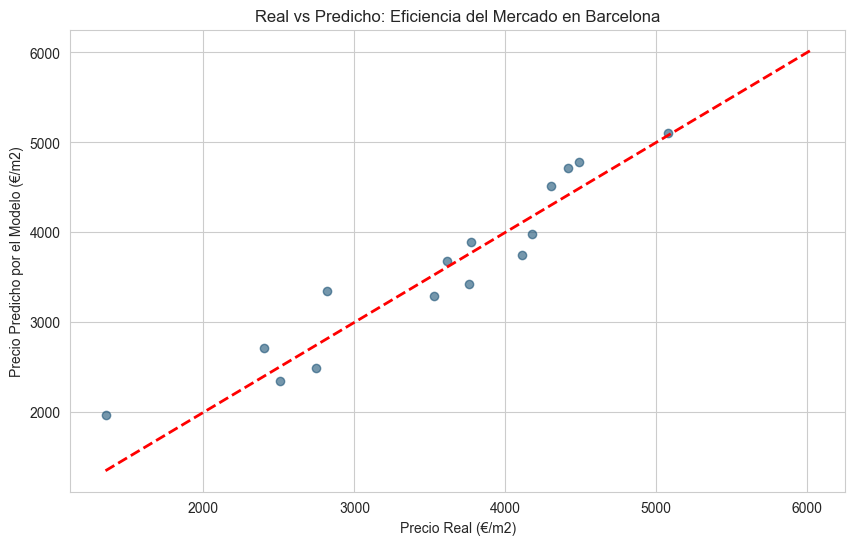

In [4]:
# 4. EVALUACIÓN Y VISUALIZACIÓN DE PRECISIÓN
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Métricas del Modelo:")
print(f"   - MAE: {mae:.2f} €/m2 (Error medio por metro cuadrado)")
print(f"   - R² Score: {r2:.2f} (Capacidad de explicación de la varianza)")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#1a5276')
plt.plot([y.min(), y.max()], [y.min(), y.max()], '--r', lw=2)
plt.title('Real vs Predicho: Eficiencia del Mercado en Barcelona')
plt.xlabel('Precio Real (€/m2)')
plt.ylabel('Precio Predicho por el Modelo (€/m2)')
plt.show()

In [5]:
# 5. BUSCANDO LA 'ORO': ANÁLISIS DE VALOR (Gaps de Precio)
# Predecimos para TODO el dataset
df['precio_estimado'] = model.predict(X)
df['desviacion_valor'] = ((df['avg_venta_23'] - df['precio_estimado']) / df['precio_estimado']) * 100

# Negativo = Posible GANGA (Infravalorado)
# Positivo = Posible SOBREVALORADO

oportunidades = df.sort_values('desviacion_valor').head(10)
print("💎 TOP 10 BARRIOS INFRAVALORADOS SEGÚN FUNDAMENTALES:")
display(oportunidades[['barrio_nombre', 'distrito_nombre', 'avg_venta_23', 'precio_estimado', 'desviacion_valor', 'segmento']])

💎 TOP 10 BARRIOS INFRAVALORADOS SEGÚN FUNDAMENTALES:


,barrio_nombre,distrito_nombre,avg_venta_23,precio_estimado,desviacion_valor,segmento
55,Vallbona,Nou Barris,1350.838672,1970.695304,-31.453702,📈 High Yield / Investment
53,Torre Baró,Nou Barris,1581.817334,1890.576085,-16.331464,📈 High Yield / Investment
28,el Coll,Gràcia,2816.464274,3344.474188,-15.787531,🏠 Stable Residential
45,el Turó de la Peira,Nou Barris,2402.220540,2711.098789,-11.393102,📈 High Yield / Investment
14,Hostafrancs,Sants-Montjuïc,3252.460856,3554.848110,-8.506334,🏠 Stable Residential
57,Baró de Viver,Sant Andreu,1710.750000,1856.990180,-7.875119,📈 High Yield / Investment
33,Can Baró,Horta-Guinardó,2724.197949,2910.934255,-6.414996,🏠 Stable Residential
54,Ciutat Meridiana,Nou Barris,1757.573161,1875.867193,-6.306098,📈 High Yield / Investment
5,la Sagrada Família,Eixample,4417.434814,4713.509826,-6.281413,🏠 Stable Residential
9,Sant Antoni,Eixample,4490.157064,4780.476639,-6.073026,🏠 Stable Residential


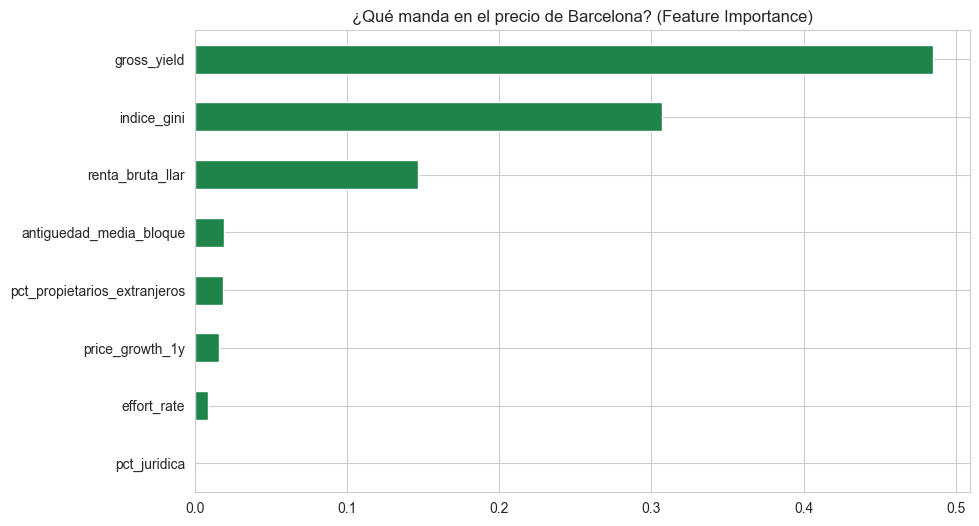

In [6]:
# 6. IMPORTANCIA DE VARIABLES
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#1e8449')
plt.title('¿Qué manda en el precio de Barcelona? (Feature Importance)')
plt.show()

In [7]:
# 7. EXPORTACIÓN FINAL
df.to_csv("../data/barcelona_ml_valuation.csv", index=False)
print("✅ Valoración de ML exportada: data/barcelona_ml_valuation.csv")

✅ Valoración de ML exportada: data/barcelona_ml_valuation.csv
